In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train = pd.read_csv('data/mnist_train.csv')
test = pd.read_csv('data/mnist_test.csv')


In [3]:
# Separate values into labels and components

X_train = train.drop(columns = ['label']).values
Y_train = train['label'].values

X_test = test.drop(columns = ['label']).values
Y_test = test['label'].values


In [4]:
from sklearn.model_selection import train_test_split

X_train_small, _, Y_train_small, _ = train_test_split(
    X_train,
    Y_train,
    train_size = 5000,
    stratify = Y_train,
    random_state = 0
)

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_small)
X_test_pca = pca.transform(X_test)
print(pca.n_components_)

149


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_pca_small = scaler.fit_transform(X_train_pca)
X_test_pca = scaler.transform(X_test_pca)

In [7]:
from sklearn.kernel_ridge import KernelRidge

def run_digit_pair(d1, d2, kernel="rbf", alpha=1e-3, gamma=0.01, degree=3, coef0=1):
    # filter PCA data
    train_mask = (Y_train_small == d1) | (Y_train_small == d2)
    test_mask  = (Y_test == d1) | (Y_test == d2)

    Xtr = X_train_pca_small[train_mask]
    Xte = X_test_pca[test_mask]

    ytr = np.where(Y_train_small[train_mask] == d1, 1, -1)
    yte = np.where(Y_test[test_mask] == d1, 1, -1)

    # normalize after filtering
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    # model
    model = KernelRidge(
        alpha=alpha,
        kernel=kernel,
        gamma=gamma if kernel == "rbf" else None,
        degree=degree,
        coef0=coef0
    )

    model.fit(Xtr, ytr)

    train_pred = np.sign(model.predict(Xtr))
    test_pred  = np.sign(model.predict(Xte))

    train_pred[train_pred == 0] = 1
    test_pred[test_pred == 0] = 1

    return {
        "pair": (d1, d2),
        "kernel": kernel,
        "train_error": np.mean(train_pred != ytr),
        "test_error": np.mean(test_pred != yte)
    }

In [8]:
pairs = [(1, 9), (3, 8), (1, 7), (5, 2)]
kernels = ["linear", "poly", "rbf"]

results = []

for pair in pairs:
    for kernel in kernels:
        results.append(run_digit_pair(*pair, kernel=kernel))

In [9]:
results_df = pd.DataFrame(results)
results_df

,pair,kernel,train_error,test_error
0,"(1, 9)",linear,0.002836,0.006996
1,"(1, 9)",poly,0.000000,0.005131
2,"(1, 9)",rbf,0.000000,0.003731
3,"(3, 8)",linear,0.023046,0.051915
4,"(3, 8)",poly,0.000000,0.021673
5,"(3, 8)",rbf,0.000000,0.027722
6,"(1, 7)",linear,0.002768,0.010171
7,"(1, 7)",poly,0.000000,0.011096
8,"(1, 7)",rbf,0.000000,0.005086
9,"(5, 2)",linear,0.017932,0.028586


In [10]:
from sklearn.preprocessing import label_binarize

Y_train_onehot = label_binarize(Y_train_small, classes=np.arange(10))
Y_test_onehot  = label_binarize(Y_test,  classes=np.arange(10))

print(Y_train_onehot.shape) 
print(Y_test_onehot.shape)   

(5000, 10)
(10000, 10)


In [11]:
kernels = [
    ("linear", {"kernel": "linear"}),
    ("poly", {"kernel": "poly", "degree": 3, "coef0": 1}),
    ("rbf", {"kernel": "rbf", "gamma": 0.01})
]

for name, params in kernels:
    krr = KernelRidge(alpha=1e-3, **params)
    krr.fit(X_train_pca_small, Y_train_onehot)

    train_scores = krr.predict(X_train_pca_small)
    test_scores  = krr.predict(X_test_pca)

    Y_train_pred = np.argmax(train_scores, axis=1)
    Y_test_pred = np.argmax(krr.predict(X_test_pca), axis=1)
    
    train_error = np.mean(Y_train_pred != Y_train_small)
    test_error  = np.mean(Y_test_pred != Y_test)

    print(f"{name} train error:", train_error)
    print(f"{name} test error:", test_error)

linear train error: 0.1398
linear test error: 0.1516
poly train error: 0.0
poly test error: 0.0575
rbf train error: 0.0
rbf test error: 0.0558


In [12]:
kernels = [
    ("poly", {"kernel": "poly", "degree": 2, "coef0": 0}),
    ("rbf", {"kernel": "rbf", "gamma": 0.01})
]

for name, params in kernels:
    krr = KernelRidge(alpha=1e-5, **params)
    krr.fit(X_train_pca_small, Y_train_onehot)

    train_scores = krr.predict(X_train_pca_small)
    test_scores  = krr.predict(X_test_pca)

    Y_train_pred = np.argmax(train_scores, axis=1)
    Y_test_pred = np.argmax(krr.predict(X_test_pca), axis=1)
    
    train_error = np.mean(Y_train_pred != Y_train_small)
    test_error  = np.mean(Y_test_pred != Y_test)

    print(f"{name} train error:", train_error)
    print(f"{name} test error:", test_error)

poly train error: 0.0
poly test error: 0.0826
rbf train error: 0.0
rbf test error: 0.0557


In [13]:
# Parameter Tuning
# c: choose c = 1 to include terms of all order ≤ d in polynomial, compare it with (x^Ty)^d
# d: sample d = 2,3,4,5. Beyond 5, overfitting becomes more of an issue
# gamma: want gamma near length scale. with these data, 0.001-0.01
# lambda (regularization): want different scales of regularization, try [1e-4, 1e-3, 1e-2]

from sklearn.model_selection import ParameterGrid

grids = [
    {"kernel": ["linear"], "alpha": [1e-5,1e-4, 1e-3, 1e-2,1e-1]},
    {"kernel": ["poly"], "alpha": [1e-5,1e-4, 1e-3, 1e-2,1e-1],
     "degree": [2, 3, 4], "coef0": [0, 1]},
    {"kernel": ["rbf"], "alpha": [1e-5,1e-4, 1e-3, 1e-2,1e-1],
     "gamma": [0.001, 0.01, 0.1]},
]

results = []

for grid in grids:
    for params in ParameterGrid(grid):
        result = run_digit_pair(1, 9, **params)
        results.append({**params, **result})


In [14]:
df = pd.DataFrame(results)

df.sort_values("test_error")

,alpha,kernel,pair,train_error,test_error,coef0,degree,gamma
42,0.00100,rbf,"(1, 9)",0.000000,0.003731,NaN,NaN,0.010
36,0.00001,rbf,"(1, 9)",0.000000,0.003731,NaN,NaN,0.010
29,0.10000,poly,"(1, 9)",0.000000,0.003731,0.0,2.0,NaN
45,0.01000,rbf,"(1, 9)",0.000000,0.003731,NaN,NaN,0.010
39,0.00010,rbf,"(1, 9)",0.000000,0.003731,NaN,NaN,0.010
47,0.10000,rbf,"(1, 9)",0.000945,0.004198,NaN,NaN,0.001
48,0.10000,rbf,"(1, 9)",0.000000,0.004198,NaN,NaN,0.010
14,0.00010,poly,"(1, 9)",0.000000,0.004664,1.0,2.0,NaN
20,0.00100,poly,"(1, 9)",0.000000,0.004664,1.0,2.0,NaN
44,0.01000,rbf,"(1, 9)",0.000000,0.004664,NaN,NaN,0.001


In [15]:
df.to_csv('parameter_tuning_results.csv')

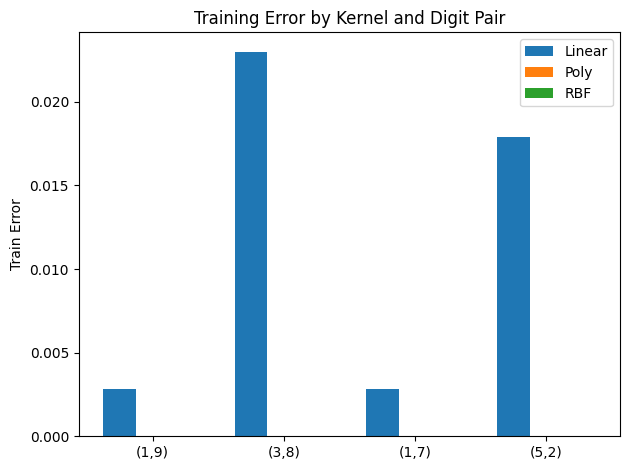

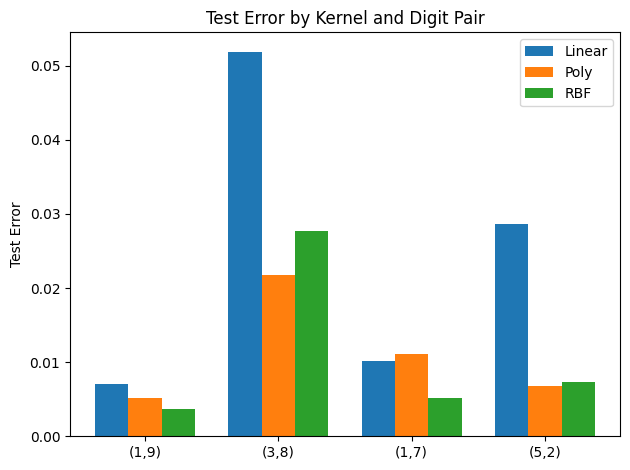

In [16]:
pairs = ['(1,9)', '(3,8)', '(1,7)', '(5,2)']

# Train errors
train_linear = [0.0028, 0.0230, 0.0028, 0.0179]
train_poly   = [0.0000, 0.0000, 0.0000, 0.0000]
train_rbf    = [0.0000, 0.0000, 0.0000, 0.0000]

# Test errors
test_linear = [0.0070, 0.0519, 0.0102, 0.0286]
test_poly   = [0.0051, 0.0217, 0.0111, 0.0068]
test_rbf    = [0.0037, 0.0277, 0.0051, 0.0073]

x = np.arange(len(pairs))
width = 0.25

# 🔹 Train error plot
plt.figure()
plt.bar(x - width, train_linear, width, label='Linear')
plt.bar(x,         train_poly,   width, label='Poly')
plt.bar(x + width, train_rbf,    width, label='RBF')

plt.xticks(x, pairs)
plt.ylabel('Train Error')
plt.title('Training Error by Kernel and Digit Pair')
plt.legend()
plt.tight_layout()
plt.show()

# 🔹 Test error plot
plt.figure()
plt.bar(x - width, test_linear, width, label='Linear')
plt.bar(x,         test_poly,   width, label='Poly')
plt.bar(x + width, test_rbf,    width, label='RBF')

plt.xticks(x, pairs)
plt.ylabel('Test Error')
plt.title('Test Error by Kernel and Digit Pair')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Test top performing kernels on one-hot encoder


# One-hot encode labels that match X_train_pca_small
Y_train_onehot = label_binarize(Y_train_small, classes=np.arange(10))

top_models = [
    {"name": "RBF alpha=1e-3", "kernel": "rbf", "alpha": 1e-3, "gamma": 0.01},
    {"name": "RBF alpha=1e-5", "kernel": "rbf", "alpha": 1e-5, "gamma": 0.01},
    {"name": "RBF alpha=1e-2", "kernel": "rbf", "alpha": 1e-2, "gamma": 0.01},
    {"name": "Poly alpha=1e-1, d=2, c=0", "kernel": "poly", "alpha": 1e-1, "degree": 2, "coef0": 0},
]

results = []

for params in top_models:
    model_params = {k: v for k, v in params.items() if k != "name"}
    model = KernelRidge(**model_params)

    model.fit(X_train_pca_small, Y_train_onehot)

    train_scores = model.predict(X_train_pca_small)
    test_scores = model.predict(X_test_pca)

    Y_train_pred = np.argmax(train_scores, axis=1)
    Y_test_pred = np.argmax(test_scores, axis=1)

    results.append({
        "model": params["name"],
        "train_error": np.mean(Y_train_pred != Y_train_small),
        "test_error": np.mean(Y_test_pred != Y_test)
    })

results_df = pd.DataFrame(results).sort_values("test_error")
results_df



,model,train_error,test_error
1,RBF alpha=1e-5,0.0,0.0557
0,RBF alpha=1e-3,0.0,0.0558
2,RBF alpha=1e-2,0.0,0.0560
3,"Poly alpha=1e-1, d=2, c=0",0.0,0.0670
